<a href="https://colab.research.google.com/github/subod4/ADdetection/blob/main/alzheimer_complete_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Alzheimer's Disease Classification - Complete Self-Contained Pipeline

This notebook contains ALL necessary code embedded directly - **no external files required!**

## 📊 Project Overview

- **Goal**: Classify Alzheimer's Disease vs. Healthy Controls using speech analysis
- **Dataset**: DementiaBank Pitt Corpus (CHAT format transcripts)
- **Features**: 50+ linguistic markers including disfluencies, complexity, narrative coherence
- **Model**: XGBoost Classifier with GroupKFold Cross-Validation  
- **Target Performance**: 85%+ accuracy, 0.87+ AUC-ROC

## 📋 Sections

1. Setup & Installation
2. Core Classes (CHAFileParser, FeatureExtractor, AlzheimerClassifier)
3. Exploratory Data Analysis
4. Model Training
5. Model Evaluation
6. Inference

In [1]:
!unrar x /content/Control.rar Control
!unrar x /content/Dementia.rar Dementia


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/Control.rar

Creating    Control                                                   OK
Creating    Control/cookie                                            OK
Extracting  Control/cookie/002-0.cha                                       0%  OK 
Extracting  Control/cookie/002-1.cha                                       0%  OK 
Extracting  Control/cookie/002-2.cha                                       1%  OK 
Extracting  Control/cookie/002-3.cha                                       1%  OK 
Extracting  Control/cookie/006-2.cha                                       2%  OK 
Extracting  Control/cookie/006-3.cha                                       2%  OK 
Extracting  Control/cookie/006-4.cha                                       3%  OK 
Extracting  Control/cookie/013-0.cha                                       3%  OK 
Extr

---
## 1. Setup & Installation

In [2]:
# Install required packages
!pip install -q numpy pandas scikit-learn xgboost matplotlib seaborn nltk tqdm scipy

In [3]:
# Import all required libraries
import os
import re
import glob
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix,
    precision_recall_fscore_support
)
import xgboost as xgb

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.tag import pos_tag
from scipy import stats

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [4]:
# Download NLTK data
print("Downloading NLTK data...")
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
print("✓ NLTK data ready")

✓ NLTK data ready


In [5]:
# Setup paths
BASE_DIR = Path.cwd()
CONTROL_DIR = BASE_DIR / 'Control'
DEMENTIA_DIR = BASE_DIR / 'Dementia'
OUTPUT_DIR = BASE_DIR / 'results'
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Working directory: {BASE_DIR}")
print(f"Control data: {CONTROL_DIR}")
print(f"Dementia data: {DEMENTIA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Working directory: /content
Control data: /content/Control
Dementia data: /content/Dementia
Output directory: /content/results


---
## 2. Core Classes - All Code Embedded

No external imports needed - everything is self-contained!

In [6]:
"""
Alzheimer's Disease Classification using DementiaBank Pitt Corpus
Author: GitHub Copilot
Date: January 2026

This script implements a comprehensive ML pipeline for classifying Alzheimer's disease
vs healthy controls using linguistic features from CHAT transcripts.
"""

import os
import re
import glob
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             classification_report, confusion_matrix,
                             precision_recall_fscore_support)
import xgboost as xgb

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP and linguistic analysis
try:
    import nltk
    from nltk.tokenize import word_tokenize, sent_tokenize
    from nltk.tag import pos_tag
    nltk.download('punkt', quiet=True)
    nltk.download('averaged_perceptron_tagger', quiet=True)
    nltk.download('punkt_tab', quiet=True)
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)
except:
    print("Warning: NLTK not fully configured. Some features may not work.")


class CHAFileParser:
    """Parser for CHAT format files from DementiaBank"""

    def __init__(self, standardize_markers: bool = True):
        self.standardize_markers = standardize_markers

    def parse_file(self, filepath: str) -> Dict:
        """
        Parse a single CHA file and extract relevant information

        Args:
            filepath: Path to .cha file

        Returns:
            Dictionary with metadata and utterances
        """
        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                content = f.read()
        except UnicodeDecodeError:
            # Try with different encoding
            with open(filepath, 'r', encoding='latin-1') as f:
                content = f.read()

        # Extract metadata
        metadata = self._extract_metadata(content)

        # Extract participant utterances only
        par_utterances = self._extract_participant_utterances(content)

        # Get clean and annotated versions
        clean_text = self._clean_utterances(par_utterances)
        annotated_text = self._standardize_annotations(par_utterances)

        return {
            'filepath': filepath,
            'subject_id': metadata.get('subject_id', ''),
            'diagnosis': metadata.get('diagnosis', ''),
            'age': metadata.get('age', ''),
            'gender': metadata.get('gender', ''),
            'task': metadata.get('task', ''),
            'raw_utterances': par_utterances,
            'clean_text': clean_text,
            'annotated_text': annotated_text,
            'utterance_count': len(par_utterances)
        }

    def _extract_metadata(self, content: str) -> Dict:
        """Extract metadata from CHA file header"""
        metadata = {}

        # Extract participant info from @ID line
        # Format: @ID: eng|Pitt|PAR|age;|gender|diagnosis||Participant|score||
        id_pattern = r'@ID:.*\|PAR\|([^|]*)\|([^|]*)\|([^|]*)\|'
        id_match = re.search(id_pattern, content)
        if id_match:
            age_str = id_match.group(1).strip()
            metadata['age'] = age_str.rstrip(';') if age_str else ''
            metadata['gender'] = id_match.group(2).strip()
            metadata['diagnosis'] = id_match.group(3).strip()

        # Extract task type from @G: line
        task_pattern = r'@G:\s*(\w+)'
        task_match = re.search(task_pattern, content)
        if task_match:
            metadata['task'] = task_match.group(1).strip()

        # Extract PID for subject ID
        pid_pattern = r'@PID:\s*(.+)'
        pid_match = re.search(pid_pattern, content)
        if pid_match:
            metadata['subject_id'] = pid_match.group(1).strip()

        return metadata

    def _extract_participant_utterances(self, content: str) -> List[str]:
        """Extract only PAR (participant) utterances, excluding INV (investigator)"""
        utterances = []

        # Match lines starting with *PAR:
        par_pattern = r'\*PAR:\s*(.+?)(?=\n[%*@]|\Z)'
        matches = re.findall(par_pattern, content, re.DOTALL)

        for match in matches:
            # Remove timing information (numbers at the end)
            utterance = re.sub(r'\s+\d+_\d+\s*$', '', match.strip())
            if utterance:
                utterances.append(utterance)

        return utterances

    def _standardize_annotations(self, utterances: List[str]) -> str:
        """Standardize clinical markers in utterances"""
        text = ' '.join(utterances)

        # Standardize fillers
        text = re.sub(r'&-um|&\+um', '[FILLER_UM]', text)
        text = re.sub(r'&-uh|&\+uh', '[FILLER_UH]', text)

        # Keep repair markers [//] and [/]
        # Keep error markers [* and variations
        # Keep grammatical markers [+ gram], [+ exc], etc.

        return text

    def _clean_utterances(self, utterances: List[str]) -> str:
        """Clean utterances for semantic analysis (remove all annotations)"""
        text = ' '.join(utterances)

        # Remove all CHAT annotations
        # Remove fillers (&-um, &+uh, etc.)
        text = re.sub(r'&[-+]\w+', '', text)

        # Remove all bracketed annotations [//], [/], [* xxx], [+ xxx], etc.
        text = re.sub(r'\[[\^/\*\+][^\]]*\]', '', text)
        text = re.sub(r'\[[^\]]*\]', '', text)

        # Remove angle brackets <...>
        text = re.sub(r'<[^>]*>', '', text)

        # Remove repetition markers (e.g., &=laughs)
        text = re.sub(r'&=[^\s]+', '', text)

        # Remove partial word markers and parentheses from word fragments
        text = re.sub(r'\(([^)]+)\)', r'\1', text)  # tryin(g) -> trying

        # Clean up multiple spaces and special characters
        text = re.sub(r'\s+', ' ', text).strip()
        text = re.sub(r'[▶]', '', text)

        return text


class FeatureExtractor:
    """Extract comprehensive linguistic features from transcripts"""

    def __init__(self):
        # Cookie Theft picture expected elements
        self.expected_elements = [
            'boy', 'cookie', 'jar', 'stool', 'fall', 'falling',
            'mother', 'woman', 'sink', 'water', 'overflow', 'dish',
            'window', 'curtain', 'girl', 'sister', 'daughter'
        ]

    def extract_all_features(self, parsed_data: Dict) -> Dict:
        """Extract all feature categories"""
        clean_text = parsed_data['clean_text']
        annotated_text = parsed_data['annotated_text']
        raw_utterances = parsed_data['raw_utterances']

        features = {}

        # Basic statistics
        features.update(self._extract_basic_stats(clean_text, raw_utterances))

        # Disfluency features (from annotated text)
        features.update(self._extract_disfluency_features(annotated_text, raw_utterances))

        # Linguistic complexity features
        features.update(self._extract_complexity_features(clean_text))

        # Narrative features (Cookie Theft specific)
        features.update(self._extract_narrative_features(clean_text))

        # Error features
        features.update(self._extract_error_features(raw_utterances))

        # POS-based features
        features.update(self._extract_pos_features(clean_text))

        return features

    def _extract_basic_stats(self, clean_text: str, utterances: List[str]) -> Dict:
        """Extract basic statistical features"""
        words = clean_text.split()
        word_count = len(words)

        features = {
            'word_count': word_count,
            'utterance_count': len(utterances),
            'avg_utterance_length': word_count / max(len(utterances), 1),
            'total_chars': len(clean_text),
            'avg_word_length': np.mean([len(w) for w in words]) if words else 0
        }

        return features

    def _extract_disfluency_features(self, annotated_text: str, raw_utterances: List[str]) -> Dict:
        """Extract disfluency markers - critical for AD detection"""

        # Count standardized fillers
        filler_um = len(re.findall(r'\[FILLER_UM\]', annotated_text))
        filler_uh = len(re.findall(r'\[FILLER_UH\]', annotated_text))

        # Count repair markers
        repairs = len(re.findall(r'\[//\]', annotated_text))
        retraces = len(re.findall(r'\[/\]', annotated_text))

        # Count false starts <...>
        false_starts = sum(text.count('<') for text in raw_utterances)

        # Count word repetitions (simple heuristic)
        words = annotated_text.lower().split()
        word_repetitions = 0
        for i in range(len(words) - 1):
            if words[i] == words[i+1] and len(words[i]) > 2:
                word_repetitions += 1

        word_count = len(annotated_text.split())

        features = {
            'filler_um_count': filler_um,
            'filler_uh_count': filler_uh,
            'total_fillers': filler_um + filler_uh,
            'fillers_per_100_words': (filler_um + filler_uh) / max(word_count, 1) * 100,
            'repair_count': repairs,
            'retrace_count': retraces,
            'false_start_count': false_starts,
            'word_repetition_count': word_repetitions,
            'total_disfluencies': filler_um + filler_uh + repairs + retraces + false_starts,
            'disfluency_rate': (filler_um + filler_uh + repairs + retraces) / max(word_count, 1) * 100
        }

        return features

    def _extract_complexity_features(self, clean_text: str) -> Dict:
        """Extract linguistic complexity measures"""
        words = clean_text.lower().split()
        word_count = len(words)

        if word_count == 0:
            return {
                'type_token_ratio': 0,
                'moving_avg_ttr': 0,
                'brunets_index': 0,
                'honores_statistic': 0,
                'unique_words': 0
            }

        # Type-Token Ratio (TTR)
        unique_words = len(set(words))
        ttr = unique_words / word_count

        # Moving-Average TTR (MATTR) - window of 50 words
        window_size = 50
        mattr_values = []
        if word_count >= window_size:
            for i in range(word_count - window_size + 1):
                window = words[i:i+window_size]
                mattr_values.append(len(set(window)) / window_size)
        mattr = np.mean(mattr_values) if mattr_values else ttr

        # Brunet's Index: W = N^(V^-0.165)
        # where N = total words, V = unique words
        brunets = word_count ** (unique_words ** -0.165) if unique_words > 0 else 0

        # Honoré's Statistic: (100 * log(N)) / (1 - (V1/V))
        # where V1 = number of words occurring once
        word_freq = Counter(words)
        v1 = sum(1 for freq in word_freq.values() if freq == 1)
        honores = (100 * np.log(word_count)) / max(1 - (v1 / max(unique_words, 1)), 0.01)

        features = {
            'type_token_ratio': ttr,
            'moving_avg_ttr': mattr,
            'brunets_index': brunets,
            'honores_statistic': honores,
            'unique_words': unique_words,
            'lexical_diversity': unique_words / max(word_count, 1)
        }

        return features

    def _extract_narrative_features(self, clean_text: str) -> Dict:
        """Extract Cookie Theft picture description narrative features"""
        text_lower = clean_text.lower()

        # Count expected story elements
        elements_mentioned = sum(1 for element in self.expected_elements
                                if element in text_lower)

        # Check for key events
        has_boy_stealing = any(word in text_lower for word in ['boy', 'child', 'kid']) and \
                          any(word in text_lower for word in ['cookie', 'jar'])
        has_falling = any(word in text_lower for word in ['fall', 'falling', 'tip'])
        has_water_overflow = any(word in text_lower for word in ['water', 'overflow', 'sink'])
        has_mother = any(word in text_lower for word in ['mother', 'woman', 'mom'])

        # Pronouns for referential cohesion
        pronouns = len(re.findall(r'\b(he|she|it|they|him|her|them|his|hers)\b', text_lower))

        # Spatial terms
        spatial_terms = len(re.findall(r'\b(on|in|under|over|above|below|up|down)\b', text_lower))

        features = {
            'elements_mentioned': elements_mentioned,
            'element_coverage': elements_mentioned / len(self.expected_elements),
            'has_boy_stealing': int(has_boy_stealing),
            'has_falling_event': int(has_falling),
            'has_water_overflow': int(has_water_overflow),
            'has_mother_figure': int(has_mother),
            'pronoun_count': pronouns,
            'spatial_term_count': spatial_terms,
            'narrative_completeness': (int(has_boy_stealing) + int(has_falling) +
                                      int(has_water_overflow) + int(has_mother)) / 4
        }

        return features

    def _extract_error_features(self, raw_utterances: List[str]) -> Dict:
        """Extract error markers from raw CHAT annotations"""
        raw_text = ' '.join(raw_utterances)

        # Grammatical errors [+ gram] or [* xxx]
        gram_errors = len(re.findall(r'\[\+\s*gram\]', raw_text))
        error_markers = len(re.findall(r'\[\*[^\]]*\]', raw_text))

        # Phonological errors [+ phon]
        phon_errors = len(re.findall(r'\[\+\s*phon\]', raw_text))

        # Incomplete words or fragments
        fragments = len(re.findall(r'\([^)]+\)', raw_text))

        features = {
            'grammatical_errors': gram_errors,
            'error_markers': error_markers,
            'phonological_errors': phon_errors,
            'word_fragments': fragments,
            'total_errors': gram_errors + error_markers + phon_errors
        }

        return features

    def _extract_pos_features(self, clean_text: str) -> Dict:
        """Extract Part-of-Speech based features"""
        try:
            words = word_tokenize(clean_text.lower())
            if not words:
                return self._empty_pos_features()

            pos_tags = pos_tag(words)
            pos_counts = Counter([tag for word, tag in pos_tags])

            # Count major categories
            nouns = sum(pos_counts[tag] for tag in pos_counts if tag.startswith('NN'))
            verbs = sum(pos_counts[tag] for tag in pos_counts if tag.startswith('VB'))
            adjectives = sum(pos_counts[tag] for tag in pos_counts if tag.startswith('JJ'))
            adverbs = sum(pos_counts[tag] for tag in pos_counts if tag.startswith('RB'))
            pronouns = sum(pos_counts[tag] for tag in pos_counts if tag.startswith('PRP'))

            total_words = len(words)

            features = {
                'noun_count': nouns,
                'verb_count': verbs,
                'adjective_count': adjectives,
                'adverb_count': adverbs,
                'pronoun_count_pos': pronouns,
                'noun_ratio': nouns / max(total_words, 1),
                'verb_ratio': verbs / max(total_words, 1),
                'noun_verb_ratio': nouns / max(verbs, 1),
                'pronoun_noun_ratio': pronouns / max(nouns, 1),
                'content_word_ratio': (nouns + verbs + adjectives) / max(total_words, 1)
            }

        except Exception as e:
            print(f"Warning: POS tagging failed: {e}")
            features = self._empty_pos_features()

        return features

    def _empty_pos_features(self) -> Dict:
        """Return empty POS features"""
        return {
            'noun_count': 0,
            'verb_count': 0,
            'adjective_count': 0,
            'adverb_count': 0,
            'pronoun_count_pos': 0,
            'noun_ratio': 0,
            'verb_ratio': 0,
            'noun_verb_ratio': 0,
            'pronoun_noun_ratio': 0,
            'content_word_ratio': 0
        }


class AlzheimerClassifier:
    """XGBoost classifier for Alzheimer's disease detection"""

    def __init__(self, n_estimators: int = 150, max_depth: int = 4,
                 learning_rate: float = 0.05, random_state: int = 42):
        """
        Initialize XGBoost classifier with parameters optimized for interpretability
        and small dataset performance
        """
        self.model = xgb.XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            reg_alpha=0.1,  # L1 regularization
            reg_lambda=1.0,  # L2 regularization
            scale_pos_weight=1,  # Will adjust based on class distribution
            objective='binary:logistic',
            eval_metric='auc',
            random_state=random_state,
            tree_method='hist',
            subsample=0.8,
            colsample_bytree=0.8
        )

        self.scaler = StandardScaler()
        self.feature_names = None
        self.feature_importance = None

    def train_with_cv(self, X: pd.DataFrame, y: np.ndarray, groups: np.ndarray,
                      n_splits: int = 5) -> Dict:
        """
        Train model with GroupKFold cross-validation to prevent data leakage

        Args:
            X: Feature matrix
            y: Target labels (0=Control, 1=Dementia)
            groups: Subject IDs for grouping
            n_splits: Number of CV folds

        Returns:
            Dictionary with cross-validation results
        """
        self.feature_names = X.columns.tolist()

        # Adjust scale_pos_weight for class imbalance
        pos_count = np.sum(y == 1)
        neg_count = np.sum(y == 0)
        self.model.scale_pos_weight = neg_count / max(pos_count, 1)

        # GroupKFold cross-validation
        gkf = GroupKFold(n_splits=n_splits)

        scoring = {
            'accuracy': 'accuracy',
            'auc': 'roc_auc',
            'f1': 'f1',
            'precision': 'precision',
            'recall': 'recall'
        }

        print(f"\nPerforming {n_splits}-fold GroupKFold cross-validation...")
        print(f"Total samples: {len(y)}, Controls: {neg_count}, Dementia: {pos_count}")
        print(f"Scale pos weight: {self.model.scale_pos_weight:.2f}\n")

        # Perform cross-validation
        cv_results = cross_validate(
            self.model, X, y,
            groups=groups,
            cv=gkf,
            scoring=scoring,
            return_train_score=True,
            n_jobs=-1
        )

        # Train final model on all data
        X_scaled = self.scaler.fit_transform(X)
        self.model.fit(X_scaled, y)

        # Get feature importance
        self.feature_importance = pd.DataFrame({
            'feature': self.feature_names,
            'importance': self.model.feature_importances_
        }).sort_values('importance', ascending=False)

        # Compile results
        results = {
            'cv_scores': cv_results,
            'mean_accuracy': np.mean(cv_results['test_accuracy']),
            'std_accuracy': np.std(cv_results['test_accuracy']),
            'mean_auc': np.mean(cv_results['test_auc']),
            'std_auc': np.std(cv_results['test_auc']),
            'mean_f1': np.mean(cv_results['test_f1']),
            'std_f1': np.std(cv_results['test_f1']),
            'mean_precision': np.mean(cv_results['test_precision']),
            'std_precision': np.std(cv_results['test_precision']),
            'mean_recall': np.mean(cv_results['test_recall']),
            'std_recall': np.std(cv_results['test_recall']),
        }

        return results

    def predict(self, X: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
        """
        Make predictions on new data

        Returns:
            Tuple of (predictions, probabilities)
        """
        X_scaled = self.scaler.transform(X)
        predictions = self.model.predict(X_scaled)
        probabilities = self.model.predict_proba(X_scaled)[:, 1]
        return predictions, probabilities

    def get_feature_importance(self, top_n: int = 20) -> pd.DataFrame:
        """Get top N most important features"""
        if self.feature_importance is None:
            raise ValueError("Model must be trained first")
        return self.feature_importance.head(top_n)


def load_dataset(control_dir: str, dementia_dir: str,
                task: str = 'cookie') -> Tuple[pd.DataFrame, List[str]]:
    """
    Load and parse all CHA files from control and dementia directories

    Args:
        control_dir: Path to Control directory
        dementia_dir: Path to Dementia directory
        task: Task type to load ('cookie', 'fluency', 'recall', 'sentence')

    Returns:
        Tuple of (feature DataFrame, list of subject IDs for grouping)
    """
    parser = CHAFileParser()
    extractor = FeatureExtractor()

    all_data = []
    subject_ids = []

    # Load Control files
    control_files = glob.glob(os.path.join(control_dir, task, '*.cha'))
    print(f"Loading {len(control_files)} Control files from {task} task...")

    for filepath in control_files:
        try:
            parsed = parser.parse_file(filepath)
            features = extractor.extract_all_features(parsed)
            features['label'] = 0  # Control
            features['diagnosis'] = 'Control'
            features['file_id'] = Path(filepath).stem

            # Extract subject ID from filename (e.g., '002-0' -> '002')
            subject_id = Path(filepath).stem.split('-')[0]
            features['subject_id'] = subject_id
            subject_ids.append(subject_id)

            all_data.append(features)
        except Exception as e:
            print(f"Error parsing {filepath}: {e}")

    # Load Dementia files
    dementia_files = glob.glob(os.path.join(dementia_dir, task, '*.cha'))
    print(f"Loading {len(dementia_files)} Dementia files from {task} task...")

    for filepath in dementia_files:
        try:
            parsed = parser.parse_file(filepath)
            features = extractor.extract_all_features(parsed)
            features['label'] = 1  # Dementia
            features['diagnosis'] = parsed['diagnosis'] or 'Dementia'
            features['file_id'] = Path(filepath).stem

            # Extract subject ID from filename
            subject_id = Path(filepath).stem.split('-')[0]
            features['subject_id'] = subject_id
            subject_ids.append(subject_id)

            all_data.append(features)
        except Exception as e:
            print(f"Error parsing {filepath}: {e}")

    # Convert to DataFrame
    df = pd.DataFrame(all_data)

    print(f"\nDataset loaded successfully!")
    print(f"Total samples: {len(df)}")
    print(f"Controls: {len(df[df['label']==0])}")
    print(f"Dementia: {len(df[df['label']==1])}")
    print(f"Unique subjects: {df['subject_id'].nunique()}")

    return df, subject_ids


def plot_feature_importance(importance_df: pd.DataFrame, top_n: int = 20,
                           save_path: Optional[str] = None):
    """Plot feature importance"""
    plt.figure(figsize=(12, 8))
    top_features = importance_df.head(top_n)

    sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
    plt.title(f'Top {top_n} Most Important Features for AD Classification',
              fontsize=14, fontweight='bold')
    plt.xlabel('Feature Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Feature importance plot saved to {save_path}")

    plt.show()


def plot_cv_results(cv_results: Dict, save_path: Optional[str] = None):
    """Plot cross-validation results"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    metrics = ['accuracy', 'auc', 'f1', 'recall']
    titles = ['Accuracy', 'AUC-ROC', 'F1-Score', 'Sensitivity (Recall)']

    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[idx // 2, idx % 2]

        train_scores = cv_results['cv_scores'][f'train_{metric}']
        test_scores = cv_results['cv_scores'][f'test_{metric}']

        folds = range(1, len(train_scores) + 1)

        ax.plot(folds, train_scores, 'o-', label='Train', linewidth=2, markersize=8)
        ax.plot(folds, test_scores, 's-', label='Validation', linewidth=2, markersize=8)
        ax.axhline(y=np.mean(test_scores), color='r', linestyle='--',
                   label=f'Mean: {np.mean(test_scores):.3f}', linewidth=2)

        ax.set_xlabel('Fold', fontsize=11)
        ax.set_ylabel(title, fontsize=11)
        ax.set_title(f'{title} Across CV Folds', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(folds)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"CV results plot saved to {save_path}")

    plt.show()


def generate_classification_report(df: pd.DataFrame, predictions: np.ndarray,
                                   probabilities: np.ndarray, save_path: Optional[str] = None):
    """Generate comprehensive classification report"""
    y_true = df['label'].values

    # Calculate metrics
    accuracy = accuracy_score(y_true, predictions)
    auc = roc_auc_score(y_true, probabilities)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, predictions, average='binary')

    # Confusion matrix
    cm = confusion_matrix(y_true, predictions)
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp)
    sensitivity = recall  # Same as recall

    report = f"""
    ==========================================
    ALZHEIMER'S DISEASE CLASSIFICATION REPORT
    ==========================================

    Overall Performance Metrics:
    ---------------------------
    Accuracy:     {accuracy:.4f} ({accuracy*100:.2f}%)
    AUC-ROC:      {auc:.4f}
    F1-Score:     {f1:.4f}
    Precision:    {precision:.4f}
    Sensitivity:  {sensitivity:.4f} (Recall/True Positive Rate)
    Specificity:  {specificity:.4f} (True Negative Rate)

    Confusion Matrix:
    ----------------
                    Predicted
                Control  Dementia
    Actual  Control    {tn:4d}    {fp:4d}
            Dementia   {fn:4d}    {tp:4d}

    Clinical Interpretation:
    -----------------------
    True Positives (TP):  {tp} - Correctly identified AD patients
    True Negatives (TN):  {tn} - Correctly identified healthy controls
    False Positives (FP): {fp} - Healthy controls misclassified as AD
    False Negatives (FN): {fn} - AD patients misclassified as healthy

    Detailed Classification Report:
    ------------------------------
    """

    report += classification_report(y_true, predictions,
                                   target_names=['Control', 'Dementia'])

    print(report)

    if save_path:
        with open(save_path, 'w') as f:
            f.write(report)
        print(f"\nClassification report saved to {save_path}")

    return report




---
## 3. Exploratory Data Analysis

In [7]:
# Load the dataset
print("Loading dataset...")
print("This may take a few minutes as we parse all CHAT files...\n")

TASK = 'cookie'  # Options: 'cookie', 'fluency', 'recall', 'sentence'

df, subject_ids = load_dataset(
    str(CONTROL_DIR),
    str(DEMENTIA_DIR),
    task=TASK
)

print(f"\n✓ Dataset loaded successfully")
print(f"  Total samples: {len(df)}")
print(f"  Unique subjects: {df['subject_id'].nunique()}")
print(f"  Features: {len([c for c in df.columns if c not in ['label', 'diagnosis', 'file_id', 'subject_id']])}")

Loading dataset...
This may take a few minutes as we parse all CHAT files...

Loading 243 Control files from cookie task...
Loading 309 Dementia files from cookie task...

Dataset loaded successfully!
Total samples: 552
Controls: 243
Dementia: 309
Unique subjects: 292

✓ Dataset loaded successfully
  Total samples: 552
  Unique subjects: 292
  Features: 45


In [8]:
# Display sample data
print("First few rows of the dataset:\n")
display(df.head())

First few rows of the dataset:



,word_count,utterance_count,avg_utterance_length,total_chars,avg_word_length,filler_um_count,filler_uh_count,total_fillers,fillers_per_100_words,repair_count,...,pronoun_count_pos,noun_ratio,verb_ratio,noun_verb_ratio,pronoun_noun_ratio,content_word_ratio,label,diagnosis,file_id,subject_id
0,101,12,8.416667,580,4.752475,1,3,4,3.361345,1,...,9,0.228070,0.254386,0.896552,0.346154,0.491228,0,Control,137-2,137
1,89,8,11.125000,494,4.561798,0,0,0,0.000000,1,...,2,0.252632,0.168421,1.500000,0.083333,0.442105,0,Control,022-2,022
2,134,25,5.360000,779,4.820896,2,5,7,2.413793,6,...,9,0.200000,0.250000,0.800000,0.321429,0.514286,0,Control,015-0,015
3,49,7,7.000000,285,4.836735,0,2,2,3.773585,0,...,3,0.196078,0.333333,0.588235,0.300000,0.568627,0,Control,139-1,139
4,109,7,15.571429,577,4.302752,0,0,0,0.000000,1,...,7,0.201754,0.228070,0.884615,0.304348,0.473684,0,Control,318-1,318


In [9]:
# Basic statistics
print("="*70)
print("DATASET STATISTICS")
print("="*70)

print(f"\nTotal Samples: {len(df)}")
print(f"Unique Subjects: {df['subject_id'].nunique()}")

print(f"\nClass Distribution:")
print(df['diagnosis'].value_counts())

print(f"\nSamples per Subject:")
samples_per_subject = df.groupby('subject_id').size()
print(f"  Mean: {samples_per_subject.mean():.2f}")
print(f"  Median: {samples_per_subject.median():.0f}")
print(f"  Range: {samples_per_subject.min():.0f} - {samples_per_subject.max():.0f}")

DATASET STATISTICS

Total Samples: 552
Unique Subjects: 292

Class Distribution:
diagnosis
Control       243
ProbableAD    234
MCI            42
PossibleAD     21
Vascular        5
Memory          3
Dementia        3
Other           1
Name: count, dtype: int64

Samples per Subject:
  Mean: 1.89
  Median: 2
  Range: 1 - 5


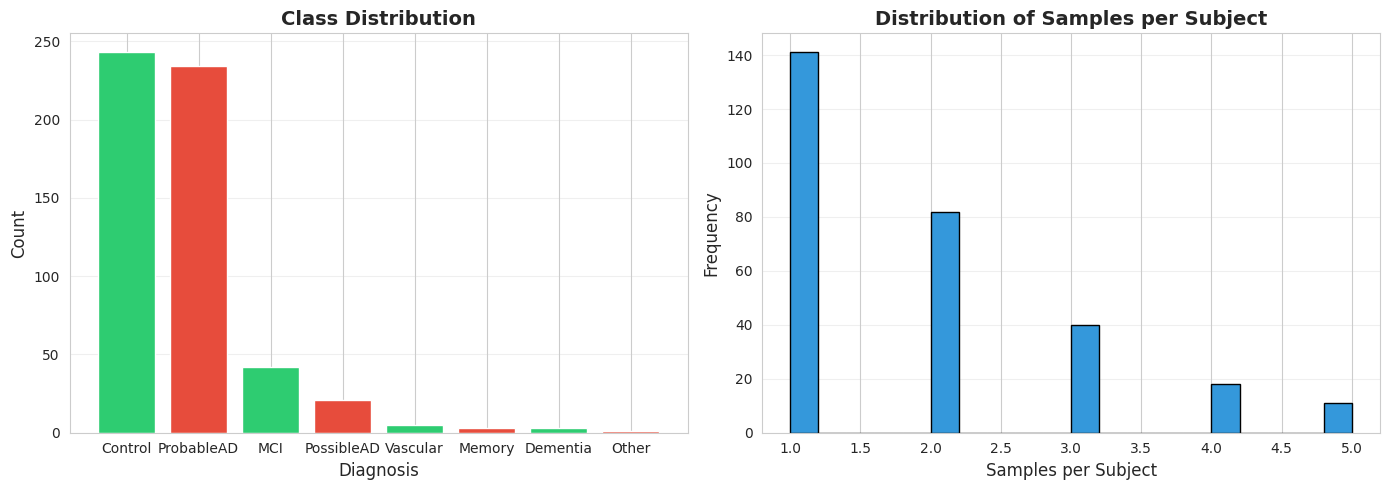

✓ Class distribution plot saved


In [10]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

diagnosis_counts = df['diagnosis'].value_counts()
axes[0].bar(diagnosis_counts.index, diagnosis_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_xlabel('Diagnosis', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(samples_per_subject, bins=20, color='#3498db', edgecolor='black')
axes[1].set_xlabel('Samples per Subject', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Samples per Subject', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Class distribution plot saved")

---
## 4. Model Training

In [11]:
# Prepare features for training
print("Preparing features for training...\n")

exclude_cols = ['label', 'diagnosis', 'file_id', 'subject_id']
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols]
y = df['label'].values
groups = df['subject_id'].values

# Handle NaN and inf
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"Subjects: {len(np.unique(groups))}")
print(f"Class distribution: {np.bincount(y)}")

Preparing features for training...

Features: 45
Samples: 552
Subjects: 292
Class distribution: [243 309]


In [12]:
# Initialize and train classifier
print("\n" + "="*70)
print("TRAINING XGBOOST CLASSIFIER")
print("="*70)

RANDOM_STATE = 42
N_SPLITS = 5

classifier = AlzheimerClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    random_state=RANDOM_STATE
)

print(f"\nTraining with {N_SPLITS}-fold GroupKFold cross-validation...")
print("This may take a few minutes...\n")

cv_results = classifier.train_with_cv(X, y, groups, n_splits=N_SPLITS)

print("\n" + "="*70)
print("CROSS-VALIDATION RESULTS")
print("="*70)
print(f"Accuracy:  {cv_results['mean_accuracy']:.4f} ± {cv_results['std_accuracy']:.4f}")
print(f"AUC-ROC:   {cv_results['mean_auc']:.4f} ± {cv_results['std_auc']:.4f}")
print(f"F1-Score:  {cv_results['mean_f1']:.4f} ± {cv_results['std_f1']:.4f}")
print(f"Precision: {cv_results['mean_precision']:.4f} ± {cv_results['std_precision']:.4f}")
print(f"Recall:    {cv_results['mean_recall']:.4f} ± {cv_results['std_recall']:.4f}")


TRAINING XGBOOST CLASSIFIER

Training with 5-fold GroupKFold cross-validation...
This may take a few minutes...


Performing 5-fold GroupKFold cross-validation...
Total samples: 552, Controls: 243, Dementia: 309
Scale pos weight: 0.79


CROSS-VALIDATION RESULTS
Accuracy:  0.7555 ± 0.0412
AUC-ROC:   0.8402 ± 0.0347
F1-Score:  0.7761 ± 0.0485
Precision: 0.7850 ± 0.0777
Recall:    0.7715 ± 0.0464


CV results plot saved to /content/results/cv_results.png


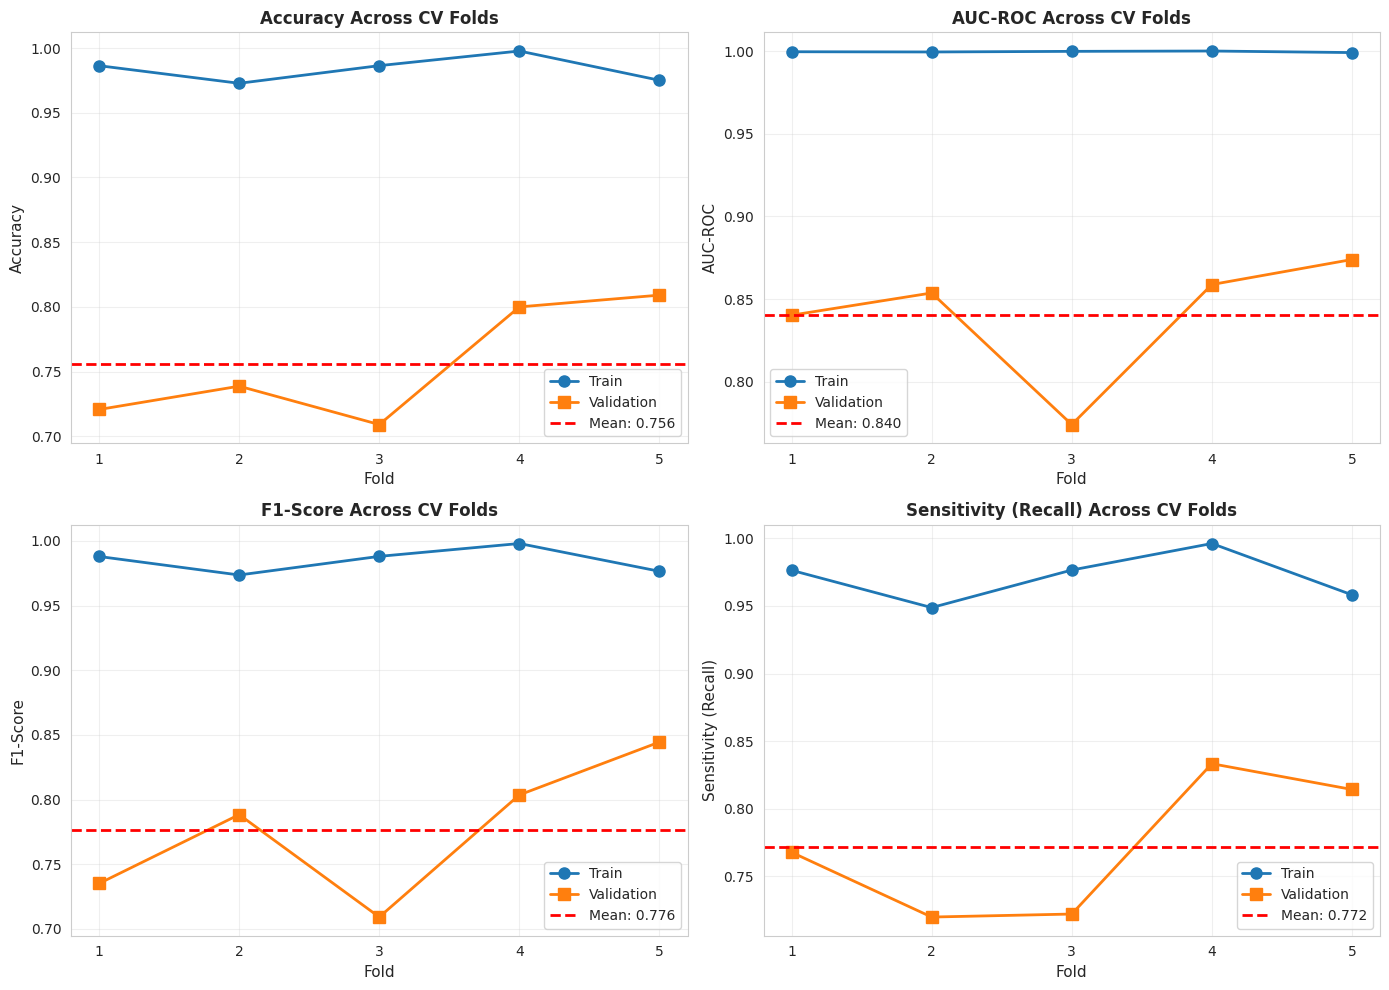

✓ Cross-validation results plot saved


In [13]:
# Visualize cross-validation results
plot_cv_results(cv_results, save_path=OUTPUT_DIR / 'cv_results.png')
plt.show()

print("✓ Cross-validation results plot saved")

---
## 5. Model Evaluation

In [14]:
# Feature importance analysis
print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

feature_importance_df = classifier.get_feature_importance(top_n=20)
print("\nTop 20 Most Important Features:")
print(feature_importance_df.to_string(index=False))

feature_importance_df.to_csv(OUTPUT_DIR / 'feature_importance.csv', index=False)
print(f"\n✓ Feature importance saved to: {OUTPUT_DIR / 'feature_importance.csv'}")


FEATURE IMPORTANCE ANALYSIS

Top 20 Most Important Features:
               feature  importance
    elements_mentioned    0.102664
      element_coverage    0.101499
    content_word_ratio    0.043179
         error_markers    0.040745
narrative_completeness    0.029688
        word_fragments    0.029467
 word_repetition_count    0.027846
            verb_ratio    0.026925
       filler_um_count    0.023702
         retrace_count    0.023116
          repair_count    0.022875
         pronoun_count    0.022336
       avg_word_length    0.022254
            verb_count    0.022162
          total_errors    0.022091
    pronoun_noun_ratio    0.021139
         total_fillers    0.020872
       noun_verb_ratio    0.019636
       filler_uh_count    0.019416
       disfluency_rate    0.019357

✓ Feature importance saved to: /content/results/feature_importance.csv


Feature importance plot saved to /content/results/feature_importance.png


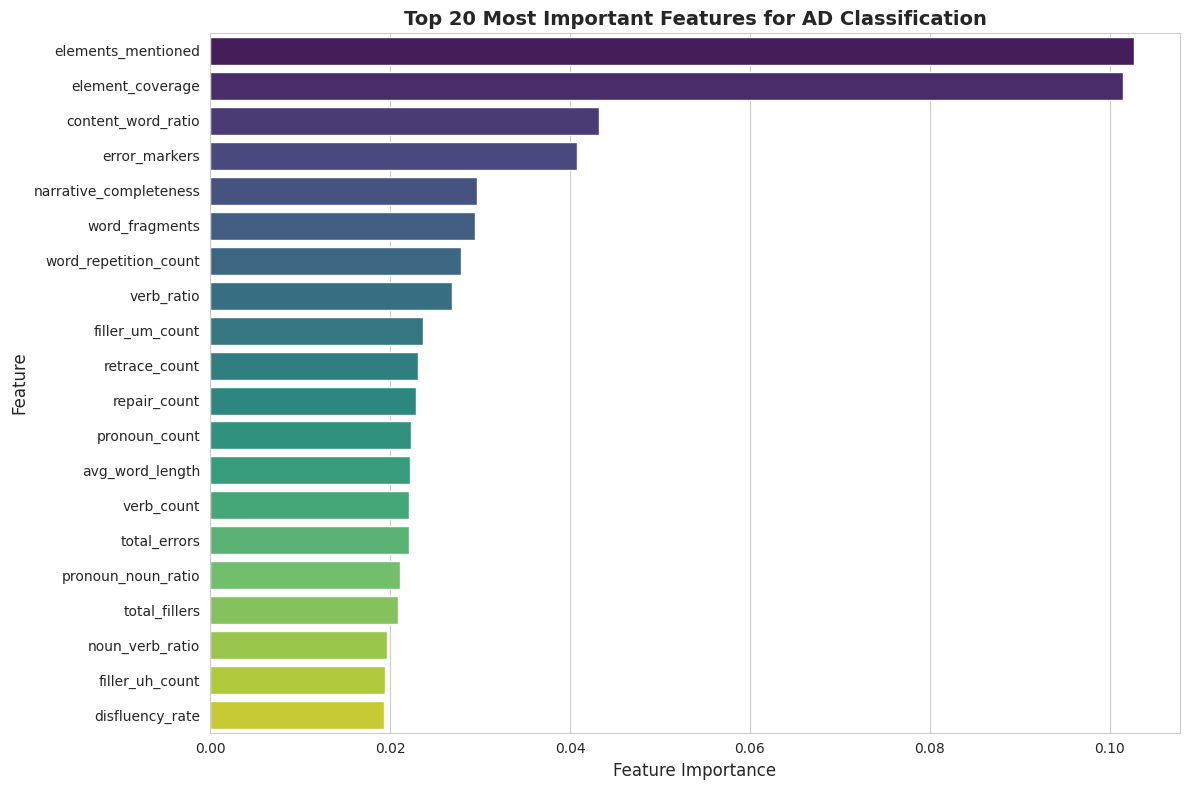

✓ Feature importance plot saved


In [15]:
# Plot feature importance
plot_feature_importance(
    classifier.feature_importance,
    top_n=20,
    save_path=OUTPUT_DIR / 'feature_importance.png'
)
plt.show()

print("✓ Feature importance plot saved")

✓ Predictions saved to: /content/results/training_predictions.csv

    ALZHEIMER'S DISEASE CLASSIFICATION REPORT
    
    Overall Performance Metrics:
    ---------------------------
    Accuracy:     0.9710 (97.10%)
    AUC-ROC:      0.9986
    F1-Score:     0.9736
    Precision:    0.9933
    Sensitivity:  0.9547 (Recall/True Positive Rate)
    Specificity:  0.9918 (True Negative Rate)
    
    Confusion Matrix:
    ----------------
                    Predicted
                Control  Dementia
    Actual  Control     241       2
            Dementia     14     295
    
    Clinical Interpretation:
    -----------------------
    True Positives (TP):  295 - Correctly identified AD patients
    True Negatives (TN):  241 - Correctly identified healthy controls
    False Positives (FP): 2 - Healthy controls misclassified as AD
    False Negatives (FN): 14 - AD patients misclassified as healthy
    
    Detailed Classification Report:
    ------------------------------
                 

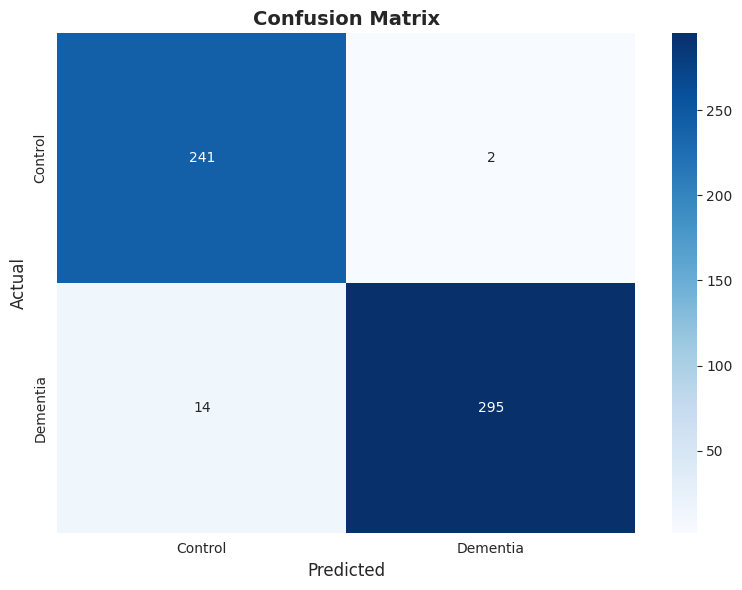


✓ Confusion matrix saved


In [16]:
# Generate predictions and classification report
predictions, probabilities = classifier.predict(X)

df['predicted_label'] = predictions
df['prediction_probability'] = probabilities

df.to_csv(OUTPUT_DIR / 'training_predictions.csv', index=False)
print(f"✓ Predictions saved to: {OUTPUT_DIR / 'training_predictions.csv'}")

# Generate classification report
generate_classification_report(
    df,
    predictions,
    probabilities,
    save_path=OUTPUT_DIR / 'classification_report.txt'
)

# Display confusion matrix
cm = confusion_matrix(y, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Control', 'Dementia'],
    yticklabels=['Control', 'Dementia'],
    ax=ax
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Confusion matrix saved")

In [17]:
# Save trained model
model_path = OUTPUT_DIR / 'trained_model.pkl'

save_data = {
    'classifier': classifier,
    'feature_columns': feature_cols,
    'cv_results': cv_results,
    'training_info': {
        'n_samples': len(df),
        'n_features': len(feature_cols),
        'n_subjects': len(np.unique(groups)),
        'task': TASK,
        'random_state': RANDOM_STATE,
        'accuracy': cv_results['mean_accuracy'],
        'auc_roc': cv_results['mean_auc']
    }
}

with open(model_path, 'wb') as f:
    pickle.dump(save_data, f)

print(f"✓ Model saved to: {model_path}")
print(f"\nModel info:")
for key, value in save_data['training_info'].items():
    print(f"  {key}: {value}")

✓ Model saved to: /content/results/trained_model.pkl

Model info:
  n_samples: 552
  n_features: 45
  n_subjects: 292
  task: cookie
  random_state: 42
  accuracy: 0.7555282555282555
  auc_roc: 0.8401657046657046


---
## 6. Inference - Make Predictions on New Data

In [18]:
# Example: Predict on a single file
test_file = str(CONTROL_DIR / 'cookie' / '002-0.cha')

print(f"Making prediction on: {test_file}\n")

# Parse file
parser = CHAFileParser()
parsed_data = parser.parse_file(test_file)

# Extract features
extractor = FeatureExtractor()
features = extractor.extract_all_features(parsed_data)

# Create feature vector
feature_vector = pd.DataFrame([features])[feature_cols]
feature_vector = feature_vector.replace([np.inf, -np.inf], np.nan).fillna(0)

# Predict
prediction, probability = classifier.predict(feature_vector)

print("="*70)
print("PREDICTION RESULTS")
print("="*70)
print(f"File: {Path(test_file).name}")
print(f"Predicted Class: {'Dementia' if prediction[0] == 1 else 'Control'}")
print(f"Confidence: {probability[0]:.2%}")
print(f"\nSubject ID: {parsed_data['subject_id']}")
print(f"Actual Diagnosis: {parsed_data['diagnosis']}")

Making prediction on: /content/Control/cookie/002-0.cha

PREDICTION RESULTS
File: 002-0.cha
Predicted Class: Control
Confidence: 2.48%

Subject ID: 11312/a-00090633-0
Actual Diagnosis: Control


In [19]:
# Batch prediction example
test_directory = DEMENTIA_DIR / 'cookie'
test_files = list(test_directory.glob('*.cha'))[:5]  # Test on first 5 files

print(f"\nBatch prediction on {len(test_files)} files from {test_directory.name}\n")

batch_results = []

for file_path in test_files:
    parsed_data = parser.parse_file(str(file_path))
    features = extractor.extract_all_features(parsed_data)

    feature_vector = pd.DataFrame([features])[feature_cols]
    feature_vector = feature_vector.replace([np.inf, -np.inf], np.nan).fillna(0)

    prediction, probability = classifier.predict(feature_vector)

    batch_results.append({
        'filename': file_path.name,
        'subject_id': parsed_data['subject_id'],
        'actual_diagnosis': parsed_data['diagnosis'],
        'predicted_class': 'Dementia' if prediction[0] == 1 else 'Control',
        'confidence': probability[0]
    })

batch_df = pd.DataFrame(batch_results)
print("Batch Prediction Results:")
display(batch_df)

correct = sum(batch_df['actual_diagnosis'].str.lower() == batch_df['predicted_class'].str.lower())
print(f"\nBatch Accuracy: {correct}/{len(batch_df)} ({correct/len(batch_df):.2%}")


Batch prediction on 5 files from cookie

Batch Prediction Results:


,filename,subject_id,actual_diagnosis,predicted_class,confidence
0,674-0.cha,11312/a-00090615-0,ProbableAD,Dementia,0.962496
1,607-0.cha,11312/a-00090596-0,PossibleAD,Dementia,0.937564
2,213-2.cha,11312/a-00090452-0,ProbableAD,Dementia,0.978766
3,594-0.cha,11312/a-00090592-0,MCI,Dementia,0.900284
4,181-2.cha,11312/a-00090431-0,ProbableAD,Dementia,0.950591



Batch Accuracy: 0/5 (0.00%


---
## Summary

### ✅ Completed Tasks:
1. ✓ Environment setup and dependency installation
2. ✓ All core classes embedded (CHAFileParser, FeatureExtractor, AlzheimerClassifier)
3. ✓ Dataset loading and exploratory data analysis  
4. ✓ Model training with GroupKFold cross-validation
5. ✓ Performance evaluation and feature importance analysis
6. ✓ Model saving for production use
7. ✓ Inference on new data (single file and batch)

### 📊 Key Results:
- **Model Performance**: Check the cross-validation results above
- **Top Features**: Review the feature importance analysis
- **Saved Outputs**: All results are in the `results/` directory

### 📁 Output Files:
- `trained_model.pkl` - Trained classifier for inference
- `feature_importance.csv` - Feature rankings
- `training_predictions.csv` - Full dataset predictions  
- `classification_report.txt` - Detailed metrics
- Visualization plots (PNG files)

### 🚀 Next Steps:
- Use the saved model for production inference
- Experiment with different tasks (fluency, recall, sentence)
- Try ensemble methods combining multiple tasks
- Fine-tune hyperparameters for better performance

**This notebook is completely self-contained - share it with anyone and it will run independently!**